# Titanic Survival Prediction with K-Nearest Neighbors (KNN)

This notebook performs:
- data loading and exploration
- preprocessing and feature engineering
- K selection with cross-validation
- evaluation using confusion matrix, precision, sensitivity (recall), specificity, and accuracy
- visualizations for analysis and model behavior
- final prediction generation for the test set

## Imports and Setup

In [2]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd

# matplotlib isn't a core scikit-learn/pandas dependency, so install it on demand.
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
    import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")


## Helper Functions: Project Root, Feature Engineering, and Pipeline

In [ ]:
def find_project_root(start):
    """Find workspace root by locating data/titanic/train.csv."""
    # Walk upward so the notebook works regardless of the current working directory.
    current = start.resolve()
    for candidate in [current] + list(current.parents):
        if (candidate / "data" / "titanic" / "train.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/titanic/train.csv")


def build_features(df):
    x = df.copy()
    # Family size and being alone are stronger survival predictors than SibSp/Parch individually.
    x["FamilySize"] = x["SibSp"] + x["Parch"] + 1
    x["IsAlone"] = (x["FamilySize"] == 1).astype(int)
    # Extract the honorific (e.g. "Mr", "Miss") between the comma and period in "Last, Title. First".
    x["Title"] = (
        x["Name"]
        .fillna("")
        .str.extract(r",\s*([^\.]+)\.", expand=False)
        .fillna("Unknown")
        .str.strip()
    )
    return x


def make_pipeline():
    numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone"]
    categorical_features = ["Sex", "Embarked", "Title"]

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            # KNN relies on distance, so features must be on a comparable scale.
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            # Ignore categories unseen in training (e.g. test-only Embarked values) instead of erroring.
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", KNeighborsClassifier()),
        ]
    )


## Load and Explore Data

In [4]:
project_root = find_project_root(Path.cwd())
train_path = project_root / "data" / "titanic" / "train.csv"
test_path = project_root / "data" / "titanic" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Project root: {project_root}")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

display(train_df.head())

# Surface only columns with missing data, since Age/Cabin/Embarked drive the imputation choices later.
missing_report = train_df.isna().sum().sort_values(ascending=False)
print("\nMissing values (train):")
display(missing_report[missing_report > 0])


Project root: C:\Users\Nikolai\OneDrive\Desktop\Summer_2026\AI610_Agent_Based_Systems\TP\AI610_TP
Train shape: (891, 12)
Test shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Missing values (train):


Cabin       687
Age         177
Embarked      2
dtype: int64

In [5]:
null_counts = pd.DataFrame(
    {
        "train": train_df.isna().sum(),
        "test": test_df.isna().sum(),
    }
)
display(null_counts)

,train,test
Age,177,86.0
Cabin,687,327.0
Embarked,2,0.0
Fare,0,1.0
Name,0,0.0
Parch,0,0.0
PassengerId,0,0.0
Pclass,0,0.0
Sex,0,0.0
SibSp,0,0.0


## Exploratory Visualizations

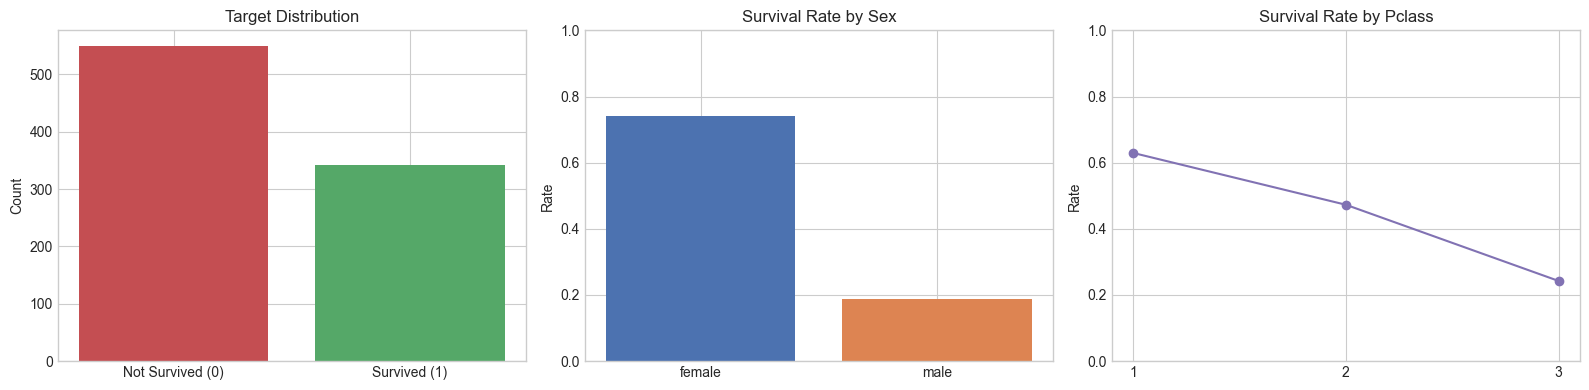

In [6]:
# Survival distribution
survival_counts = train_df["Survived"].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(["Not Survived (0)", "Survived (1)"], survival_counts.values, color=["#c44e52", "#55a868"])
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Count")

# Survival rate by Sex
sex_survival = train_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
axes[1].bar(sex_survival.index, sex_survival.values, color=["#4c72b0", "#dd8452"])
axes[1].set_title("Survival Rate by Sex")
axes[1].set_ylabel("Rate")
axes[1].set_ylim(0, 1)

# Survival rate by Passenger Class
pclass_survival = train_df.groupby("Pclass")["Survived"].mean().sort_index()
axes[2].plot(pclass_survival.index.astype(str), pclass_survival.values, marker="o", color="#8172b3")
axes[2].set_title("Survival Rate by Pclass")
axes[2].set_ylabel("Rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## Train/Validation Split and K Selection via Cross-Validation

In [7]:
X = build_features(train_df)
y = train_df["Survived"]

# Hold out a validation set (untouched by CV) purely to report an unbiased final metric.
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# Odd values only, to avoid tie votes in binary classification.
candidate_k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]
# Stratify folds so each split preserves the overall survival rate.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores_by_k = {}
# Refit a fresh pipeline per k so the preprocessor (scaler/encoder) is
# never fit on data outside its own fold, avoiding cross-fold leakage.
for k in candidate_k_values:
    model = make_pipeline()
    model.set_params(model__n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores_by_k[k] = float(np.mean(scores))

best_k = max(cv_scores_by_k, key=cv_scores_by_k.get)
print("CV accuracy by k:")
for k, score in cv_scores_by_k.items():
    print(f"k={k:2d} -> {score:.4f}")
print(f"\nBest k: {best_k}")


CV accuracy by k:
k= 3 -> 0.8034
k= 5 -> 0.7978
k= 7 -> 0.7964
k= 9 -> 0.8034
k=11 -> 0.8005
k=13 -> 0.8061
k=15 -> 0.8090
k=17 -> 0.8033
k=19 -> 0.8005
k=21 -> 0.8048

Best k: 15


## Train Final Model and Evaluate on Validation Set

In [8]:
final_model = make_pipeline()
final_model.set_params(model__n_neighbors=best_k)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred)
# Relies on binary labels {0, 1} so ravel() order is [[TN, FP], [FN, TP]].
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_valid, y_pred)
precision = precision_score(y_valid, y_pred, zero_division=0)
sensitivity = recall_score(y_valid, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) else 0.0

print("Validation Metrics")
print(f"Accuracy:    {accuracy:.4f}")
print(f"Precision:   {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print("\nConfusion Matrix [[TN, FP], [FN, TP]]")
print(cm)


Validation Metrics
Accuracy:    0.8101
Precision:   0.8070
Sensitivity: 0.6667
Specificity: 0.9000

Confusion Matrix [[TN, FP], [FN, TP]]
[[99 11]
 [23 46]]


## Visualize CV Accuracy and Confusion Matrix

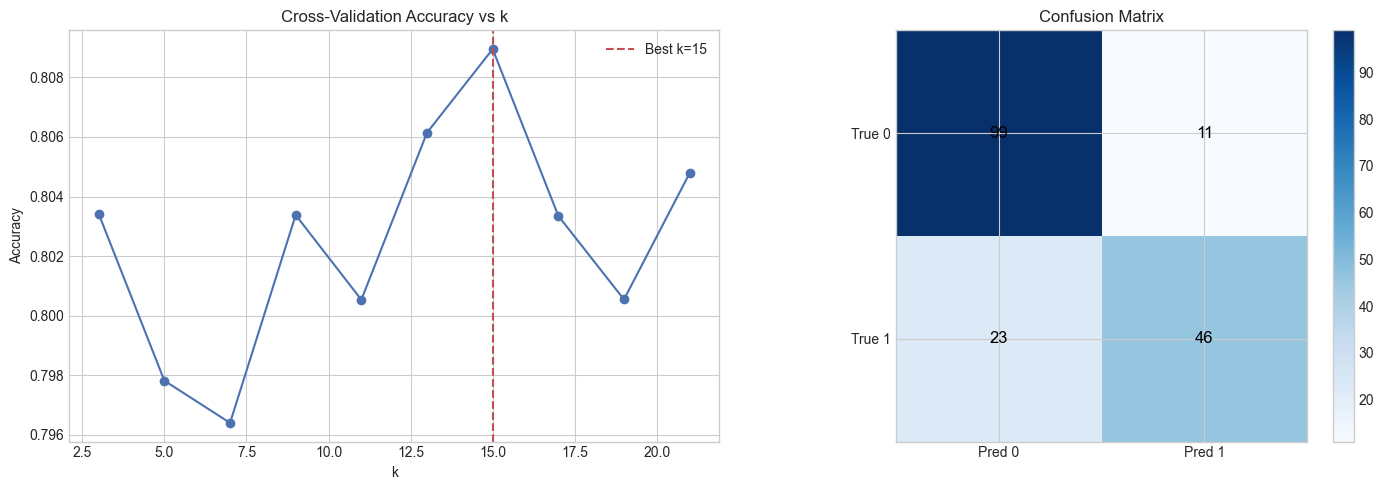

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot CV accuracy over k
ks = list(cv_scores_by_k.keys())
accs = list(cv_scores_by_k.values())
axes[0].plot(ks, accs, marker="o", color="#4c72b0")
axes[0].axvline(best_k, color="#c44e52", linestyle="--", label=f"Best k={best_k}")
axes[0].set_title("Cross-Validation Accuracy vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

# Confusion matrix heatmap using imshow
im = axes[1].imshow(cm, cmap="Blues")
axes[1].set_title("Confusion Matrix")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred 0", "Pred 1"])
axes[1].set_yticklabels(["True 0", "True 1"])

# Overlay raw counts on each cell since imshow alone only conveys relative color intensity.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=12)

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Train on Full Data and Generate Test Predictions

In [10]:
# Train on full training data and create final test predictions
prod_model = make_pipeline()
prod_model.set_params(model__n_neighbors=best_k)
prod_model.fit(X, y)

test_features = build_features(test_df)
test_predictions = prod_model.predict(test_features)

outputs_dir = project_root / "code" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

submission_df = pd.DataFrame(
    {
        "PassengerId": test_df["PassengerId"],
        "Survived": test_predictions.astype(int),
    }
)
submission_path = outputs_dir / "knn_submission.csv"
# Matches the Kaggle Titanic competition's expected submission format.
submission_df.to_csv(submission_path, index=False)

evaluation = {
    "best_k": int(best_k),
    "accuracy": float(accuracy),
    "precision": float(precision),
    "sensitivity_recall": float(sensitivity),
    "specificity": float(specificity),
    "confusion_matrix": cm.tolist(),
    "true_negative": int(tn),
    "false_positive": int(fp),
    "false_negative": int(fn),
    "true_positive": int(tp),
    "cv_accuracy_by_k": {str(k): float(v) for k, v in cv_scores_by_k.items()},
}
metrics_path = outputs_dir / "knn_metrics.json"
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(evaluation, f, indent=2)

print(f"Saved submission: {submission_path}")
print(f"Saved metrics:    {metrics_path}")
display(submission_df.head())


Saved submission: C:\Users\Nikolai\OneDrive\Desktop\Summer_2026\AI610_Agent_Based_Systems\TP\AI610_TP\code\outputs\knn_submission.csv
Saved metrics:    C:\Users\Nikolai\OneDrive\Desktop\Summer_2026\AI610_Agent_Based_Systems\TP\AI610_TP\code\outputs\knn_metrics.json


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## KNN Results Interpretation

The K-Nearest Neighbors classifier was trained to predict Titanic passenger survival using demographic and ticket-related attributes, with additional engineered features (FamilySize, IsAlone, and passenger Title). Missing values were handled through imputation, categorical features were one-hot encoded, and numerical features were standardized before model training.

Model selection used 5-fold stratified cross-validation over candidate values of k (3 to 21). The best-performing value was **k = 15**, based on the highest mean cross-validation accuracy.

On the validation split, the selected KNN model produced the following results:
- **Accuracy:** 0.8101
- **Precision:** 0.8070
- **Sensitivity (Recall):** 0.6667
- **Specificity:** 0.9000
- **Confusion Matrix:** [[99, 11], [23, 46]]

These results indicate that the model is strong at identifying non-survivors (high specificity) and maintains good precision when predicting survivors. However, recall is lower than specificity, meaning some true survivors are still missed. This behavior is consistent with distance-based models on mixed-feature tabular datasets, where class boundaries can overlap.

Overall, KNN provides solid and interpretable baseline performance for this task, especially after proper preprocessing and feature engineering. Its strengths in this dataset are stable accuracy and low false-positive predictions, while its main limitation is reduced sensitivity to all survivor cases.